# Análisis de Datos - Cáncer de Mama (Wisconsin Breast Cancer Dataset)

**Equipo:** Santiago Calle – Alexander Luna  - Alvaro Quisilema   
**Programa:** Maestría en Ciencia de Datos y Máquinas de Aprendizaje  
**Fecha:** 19 de mayo 2026

**Objetivo:** Realizar el preprocesamiento y análisis exploratorio de datos (EDA) del dataset de cáncer de mama para el propósito de predicción (Maligno vs Benigno).

---
## FASE I - Preprocesamiento de Datos

### 1. Importar librerías

In [1]:
# Librerías principales
import numpy as np
import pandas as pd

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Normalización
from sklearn.preprocessing import MinMaxScaler

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

### 2. Cargar el conjunto de datos

In [2]:
# URLs de los archivos CSV en GitHub
train_path = 'https://raw.githubusercontent.com/Alexander-Luna/UIDE-HERRAMIENTAS-PARA-DATA-SCIENCE/main/Semana1/Tarea/wdbc_train.csv'
test_path = 'https://raw.githubusercontent.com/Alexander-Luna/UIDE-HERRAMIENTAS-PARA-DATA-SCIENCE/main/Semana1/Tarea/wdbc_test.csv'

# Leer los archivos CSV
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print('--- Dataset de Entrenamiento (primeras 5 filas) ---')
print(df_train.head())
print(f'\nDimensiones: {df_train.shape}')

print('\n--- Dataset de Prueba (primeras 5 filas) ---')
print(df_test.head())
print(f'\nDimensiones: {df_test.shape}')

--- Dataset de Entrenamiento (primeras 5 filas) ---
         id diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  co

### 3. Entendimiento de los datos

In [3]:
# Información general del dataset de entrenamiento
print('=== INFORMACIÓN DEL DATASET DE ENTRENAMIENTO ===')
print(df_train.info())

print('\n=== INFORMACIÓN DEL DATASET DE PRUEBA ===')
print(df_test.info())

=== INFORMACIÓN DEL DATASET DE ENTRENAMIENTO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  455 non-null    int64  
 1   diagnosis           455 non-null    object 
 2   radius1             455 non-null    float64
 3   texture1            455 non-null    float64
 4   perimeter1          455 non-null    float64
 5   area1               455 non-null    float64
 6   smoothness1         455 non-null    float64
 7   compactness1        455 non-null    float64
 8   concavity1          455 non-null    float64
 9   concave_points1     455 non-null    float64
 10  symmetry1           455 non-null    float64
 11  fractal_dimension1  455 non-null    float64
 12  radius2             455 non-null    float64
 13  texture2            455 non-null    float64
 14  perimeter2          455 non-null    float64
 15  area2   

In [4]:
# Estadísticas descriptivas del dataset de entrenamiento
print('=== ESTADÍSTICAS DESCRIPTIVAS (TRAIN) ===')
df_train.describe()

=== ESTADÍSTICAS DESCRIPTIVAS (TRAIN) ===


,id,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,4.550000e+02,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,2.713560e+07,14.235347,18.989495,92.703626,663.945714,0.096464,0.104998,0.091380,0.050351,0.182320,...,16.450044,25.411033,108.434637,898.830110,0.132548,0.258022,0.278478,0.117214,0.294085,0.084015
std,1.114952e+08,3.501131,4.082756,24.121930,347.787697,0.013702,0.053867,0.080748,0.039167,0.028121,...,4.835225,6.048317,33.481061,565.204774,0.023018,0.162487,0.212058,0.066850,0.064486,0.018423
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.116700,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.650025e+05,11.780000,16.020000,75.485000,427.950000,0.086675,0.065090,0.028860,0.020365,0.162400,...,13.060000,20.870000,84.470000,517.950000,0.116600,0.147500,0.112100,0.063295,0.253150,0.071270
50%,8.971370e+05,13.460000,18.660000,87.020000,559.200000,0.096460,0.092420,0.066510,0.035280,0.180600,...,15.030000,25.200000,98.370000,698.700000,0.131500,0.215600,0.231800,0.101700,0.284200,0.080090
75%,8.813003e+06,16.130000,21.550000,106.450000,804.100000,0.105400,0.130600,0.135100,0.077415,0.196600,...,19.515000,29.255000,128.900000,1170.000000,0.146450,0.345600,0.391600,0.171000,0.321100,0.092165
max,9.111573e+08,28.110000,39.280000,188.500000,2499.000000,0.144700,0.345400,0.426800,0.201200,0.304000,...,33.130000,49.540000,229.300000,3432.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 4. Preprocesamiento

#### 4.1 Sustituir M por 1 y B por 0

In [5]:
# Reemplazar las etiquetas de diagnóstico: Maligno (M) = 1, Benigno (B) = 0
df_train['diagnosis'] = df_train['diagnosis'].replace({'B': 0, 'M': 1})
df_test['diagnosis'] = df_test['diagnosis'].replace({'B': 0, 'M': 1})

print('Valores únicos en diagnosis (train):', df_train['diagnosis'].unique())
print('Valores únicos en diagnosis (test):', df_test['diagnosis'].unique())

Valores únicos en diagnosis (train): [1 0]
Valores únicos en diagnosis (test): [0 1]


/tmp/ipykernel_851/2783054707.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['diagnosis'] = df_train['diagnosis'].replace({'B': 0, 'M': 1})
/tmp/ipykernel_851/2783054707.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['diagnosis'] = df_test['diagnosis'].replace({'B': 0, 'M': 1})


#### 4.2 Eliminar la columna ID

In [6]:
# Descartar la columna 'id' ya que no aporta información al análisis
df_train = df_train.drop(['id'], axis=1)
df_test = df_test.drop(['id'], axis=1)

print('Dimensiones después de eliminar ID:')
print(f'  Train: {df_train.shape}')
print(f'  Test:  {df_test.shape}')
print('\nColumnas restantes:', list(df_train.columns))

Dimensiones después de eliminar ID:
  Train: (455, 31)
  Test:  (114, 31)

Columnas restantes: ['diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


#### 4.3 Verificar valores perdidos

In [7]:
# Verificar datos faltantes en ambos datasets
print('=== VALORES PERDIDOS (TRAIN) ===')
nulos_train = df_train.isnull().sum()
print(nulos_train[nulos_train > 0] if nulos_train.sum() > 0 else 'No se encontraron valores perdidos.')

print('\n=== VALORES PERDIDOS (TEST) ===')
nulos_test = df_test.isnull().sum()
print(nulos_test[nulos_test > 0] if nulos_test.sum() > 0 else 'No se encontraron valores perdidos.')

=== VALORES PERDIDOS (TRAIN) ===
No se encontraron valores perdidos.

=== VALORES PERDIDOS (TEST) ===
No se encontraron valores perdidos.


#### 4.4 Normalización de datos

In [8]:
# Seleccionar columnas a normalizar (todas excepto diagnosis)
columnas_medicas = [col for col in df_train.columns if col != 'diagnosis']

# Inicializar el escalador MinMax (rango 0 a 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# fit_transform en TRAIN: aprende los mínimos/máximos y transforma
df_train[columnas_medicas] = scaler.fit_transform(df_train[columnas_medicas])

# transform en TEST: usa los mismos parámetros del TRAIN (evita data leakage)
df_test[columnas_medicas] = scaler.transform(df_test[columnas_medicas])

print('Normalización completada.')
print('\nPrimeras filas del dataset normalizado (train):')
df_train.head()

# Guardar los datasets procesados y normalizados
df_train.to_csv('cancer_train_procesado.csv', index=False, sep=',', encoding='utf-8')
df_test.to_csv('cancer_test_procesado.csv', index=False, sep=',', encoding='utf-8')

print('Archivos CSV guardados exitosamente.')

Normalización completada.

Primeras filas del dataset normalizado (train):
Archivos CSV guardados exitosamente.


---
## FASE II - Análisis Exploratorio de Datos (EDA)

### 1. Distribución de la variable objetivo (diagnosis)

Es fundamental conocer la proporción entre casos benignos y malignos para entender si existe desbalance en los datos.

/tmp/ipykernel_851/378096093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='diagnosis', palette=['#2ecc71', '#e74c3c'])


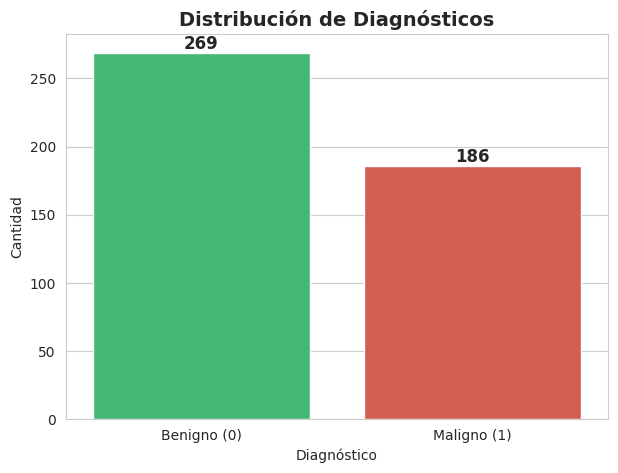


Porcentaje de malignos: 40.9%


In [9]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_train, x='diagnosis', palette=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])
plt.title('Distribución de Diagnósticos', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico')
plt.ylabel('Cantidad')

# Agregar conteo sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

print(f'\nPorcentaje de malignos: {df_train["diagnosis"].mean()*100:.1f}%')

Se observa un ligero desbalance en los datos, con mayor cantidad de casos benignos que malignos. Esto es importante tenerlo en cuenta para futuros modelos de predicción, ya que un modelo podría sesgarse hacia la clase mayoritaria.

### 2. Distribución de variables principales (Histogramas)

Se seleccionan las variables de media (`radius1`, `texture1`, `perimeter1`, `area1`, `smoothness1`, `compactness1`) por ser las mediciones directas más representativas de las características del tumor.

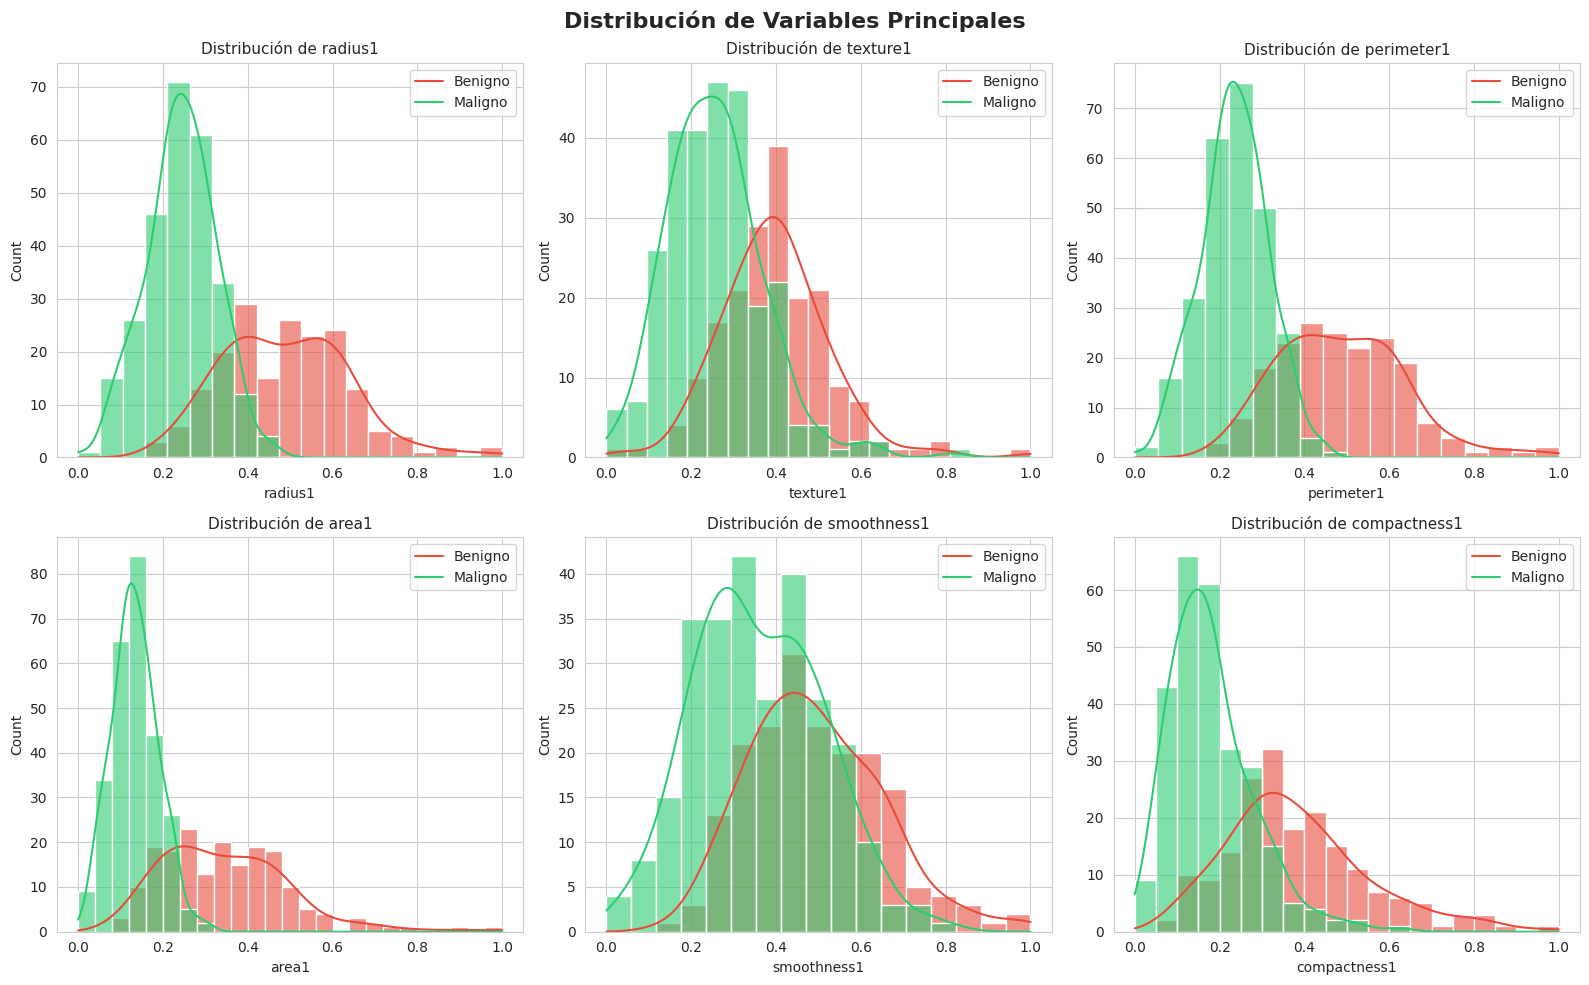

In [10]:
variables_principales = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables Principales', fontsize=16, fontweight='bold')

for i, var in enumerate(variables_principales):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=df_train, x=var, hue='diagnosis', kde=True, ax=ax,
                 palette=['#2ecc71', '#e74c3c'], alpha=0.6)
    ax.set_title(f'Distribución de {var}', fontsize=11)
    ax.legend(['Benigno', 'Maligno'])

plt.tight_layout()
plt.show()

Las variables `radius1`, `perimeter1` y `area1` muestran una clara separación entre tumores benignos y malignos: los tumores malignos tienden a tener valores más altos. Esto indica que el tamaño del tumor es un factor determinante para la clasificación. Variables como `texture1` y `smoothness1` muestran mayor solapamiento entre ambas clases, lo que sugiere menor poder discriminativo por sí solas.

### 3. Boxplots por diagnóstico

Los boxplots permiten comparar la distribución de cada variable entre tumores benignos y malignos, e identificar outliers.

/tmp/ipykernel_851/35076455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='diagnosis', y=var, ax=ax,
/tmp/ipykernel_851/35076455.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benigno', 'Maligno'])
/tmp/ipykernel_851/35076455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='diagnosis', y=var, ax=ax,
/tmp/ipykernel_851/35076455.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benigno', 'Maligno'])
/tmp/ipykernel_851/35076455.py:6: Fu

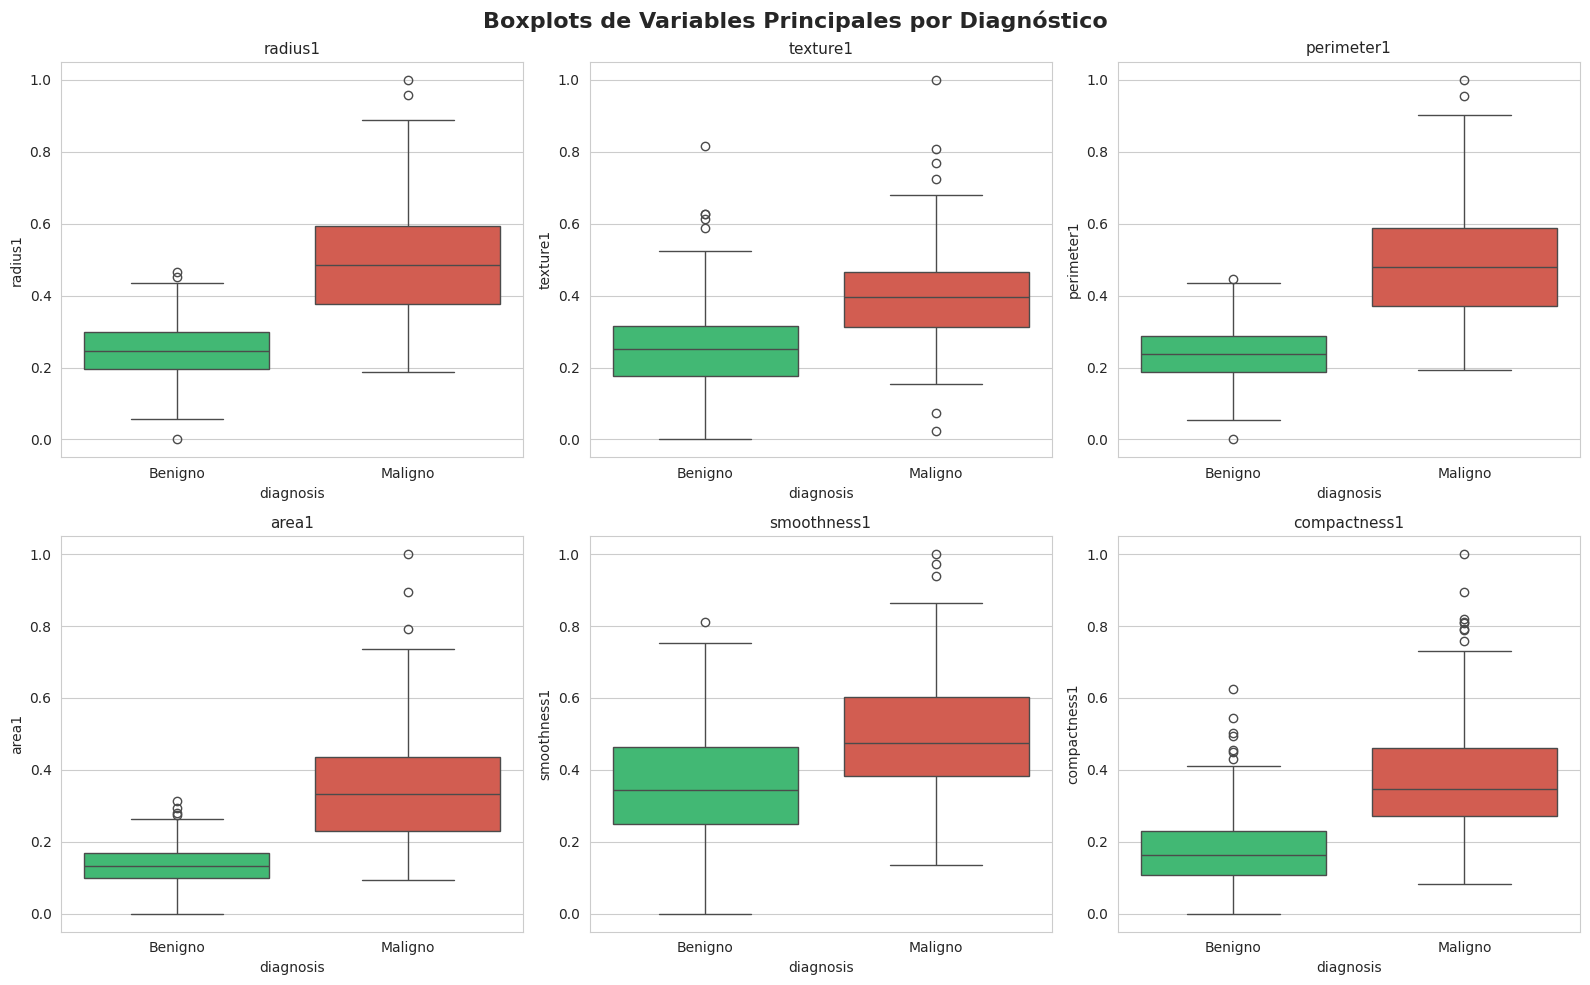

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots de Variables Principales por Diagnóstico', fontsize=16, fontweight='bold')

for i, var in enumerate(variables_principales):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_train, x='diagnosis', y=var, ax=ax,
                palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_title(f'{var}', fontsize=11)

plt.tight_layout()
plt.show()

Los boxplots confirman lo observado en los histogramas. Las variables `radius1`, `perimeter1` y `area1` presentan medianas notablemente distintas entre ambos grupos, lo que refuerza su utilidad para la predicción. Se detectan algunos outliers, especialmente en `area1` para tumores malignos, que podrían corresponder a tumores de gran tamaño.

### 4. Matriz de correlación

La matriz de correlación nos ayuda a identificar las relaciones lineales entre variables y detectar posibles redundancias (multicolinealidad).

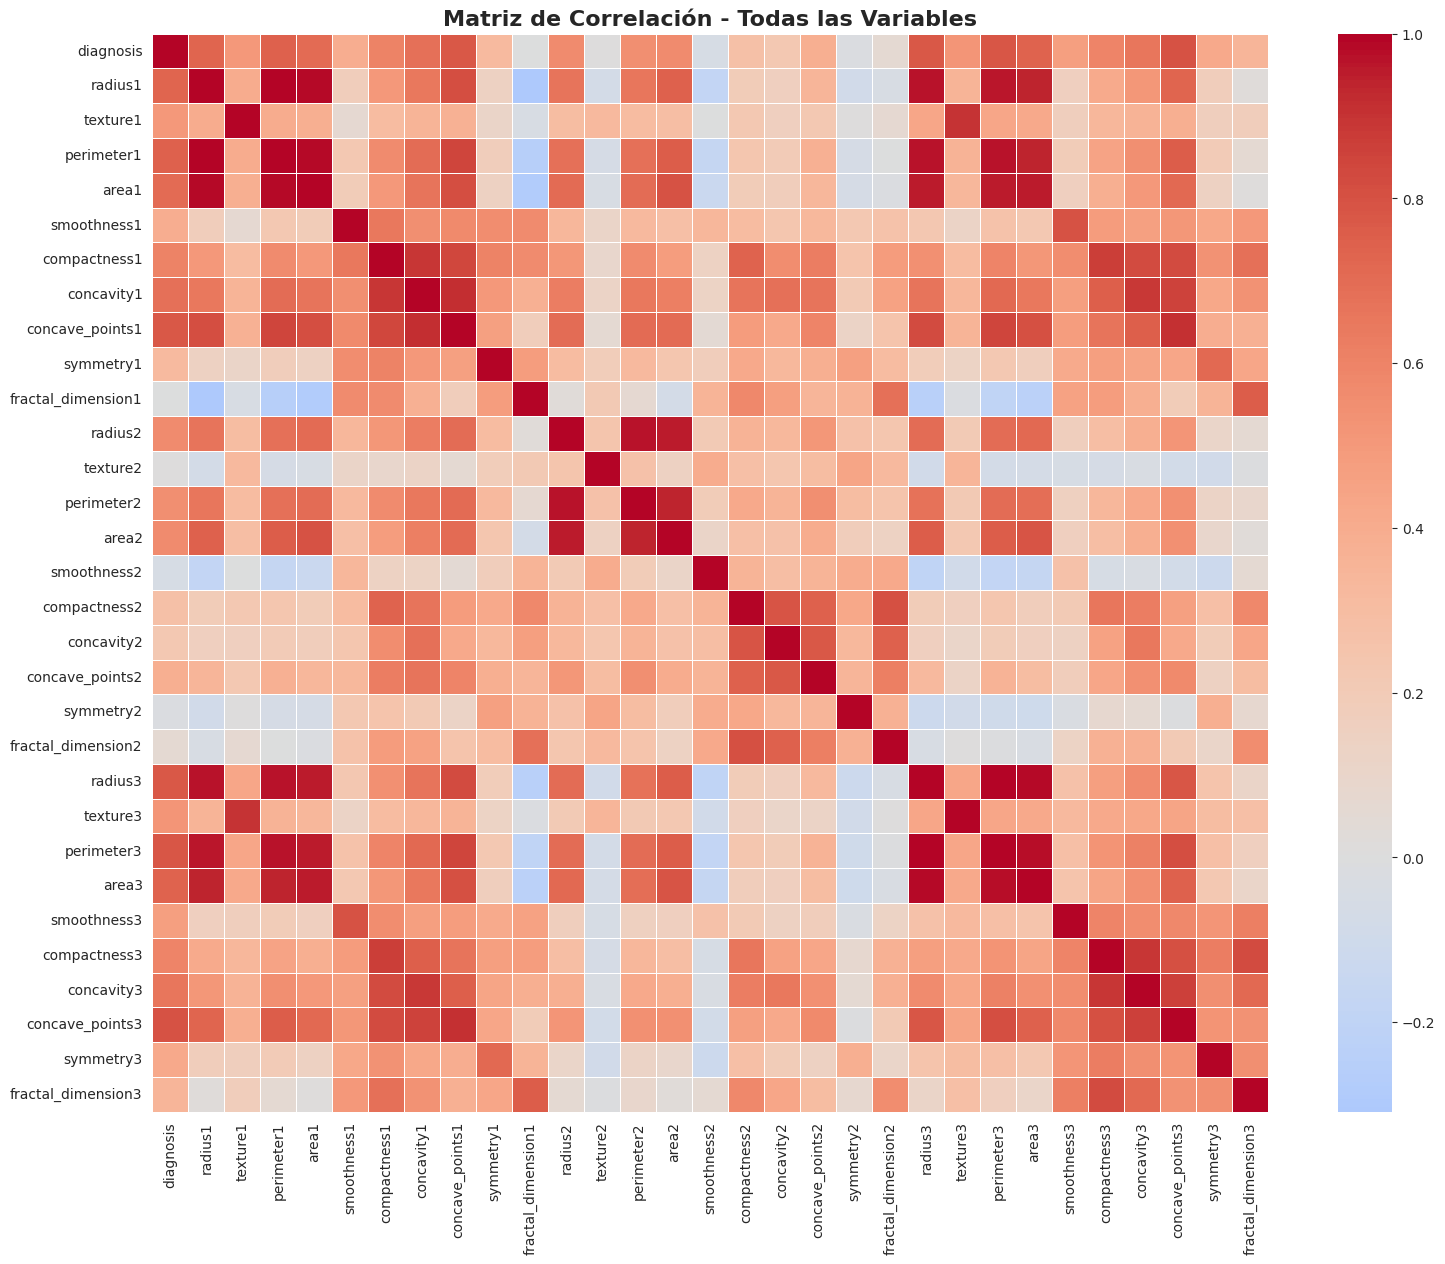

In [12]:
# Matriz de correlación completa
correlacion = df_train.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(correlacion, cmap='coolwarm', center=0, annot=False,
            linewidths=0.5, fmt='.1f')
plt.title('Matriz de Correlación - Todas las Variables', fontsize=16, fontweight='bold')
plt.show()

**Interpretación:** Se observa una alta correlación entre variables relacionadas con el tamaño del tumor (radius, perimeter, area), lo cual es esperado ya que son medidas geométricamente dependientes. Esta multicolinealidad sugiere que en un modelo predictivo no sería necesario incluir todas estas variables, ya que aportan información redundante.

### 5. Variables más correlacionadas con el diagnóstico

Top 10 variables más correlacionadas con el diagnóstico:
concave_points3    0.800212
perimeter3         0.784807
radius3            0.777265
concave_points1    0.770923
perimeter1         0.740257
area3              0.734534
radius1            0.727111
area1              0.704369
concavity1         0.680258
concavity3         0.661189
Name: diagnosis, dtype: float64


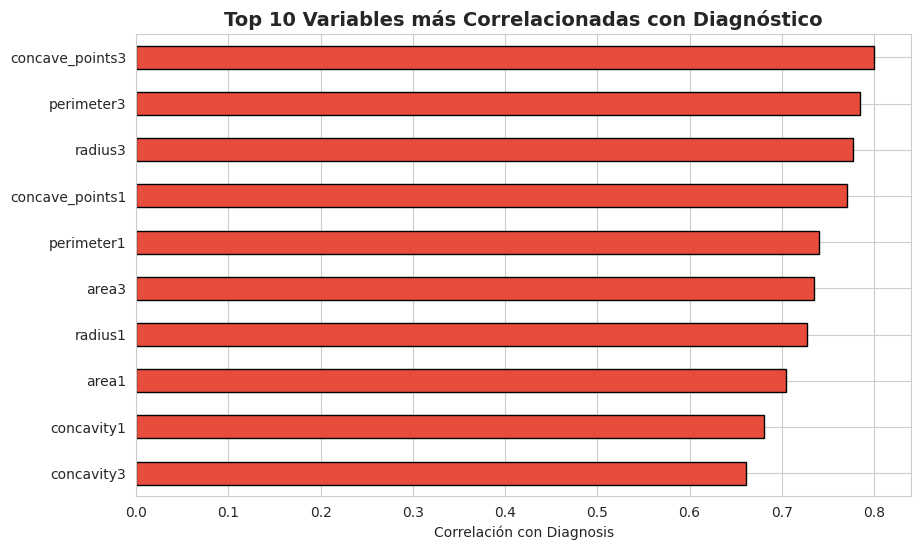

In [13]:
# Top 10 variables más correlacionadas con diagnosis
corr_diagnosis = correlacion['diagnosis'].drop('diagnosis').sort_values(ascending=False)

print('Top 10 variables más correlacionadas con el diagnóstico:')
print(corr_diagnosis.head(10))

plt.figure(figsize=(10, 6))
corr_diagnosis.head(10).plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Top 10 Variables más Correlacionadas con Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('Correlación con Diagnosis')
plt.gca().invert_yaxis()
plt.show()

Las variables con mayor correlación positiva con el diagnóstico maligno son las relacionadas con el tamaño y la concavidad del tumor. Esto indica que tumores más grandes y con bordes más irregulares tienen mayor probabilidad de ser malignos. Estas variables serían las más relevantes como predictoras en un modelo de clasificación.

### 6. Pairplot de variables más relevantes

El pairplot permite visualizar simultáneamente las relaciones entre pares de variables y su distribución, coloreadas por diagnóstico.

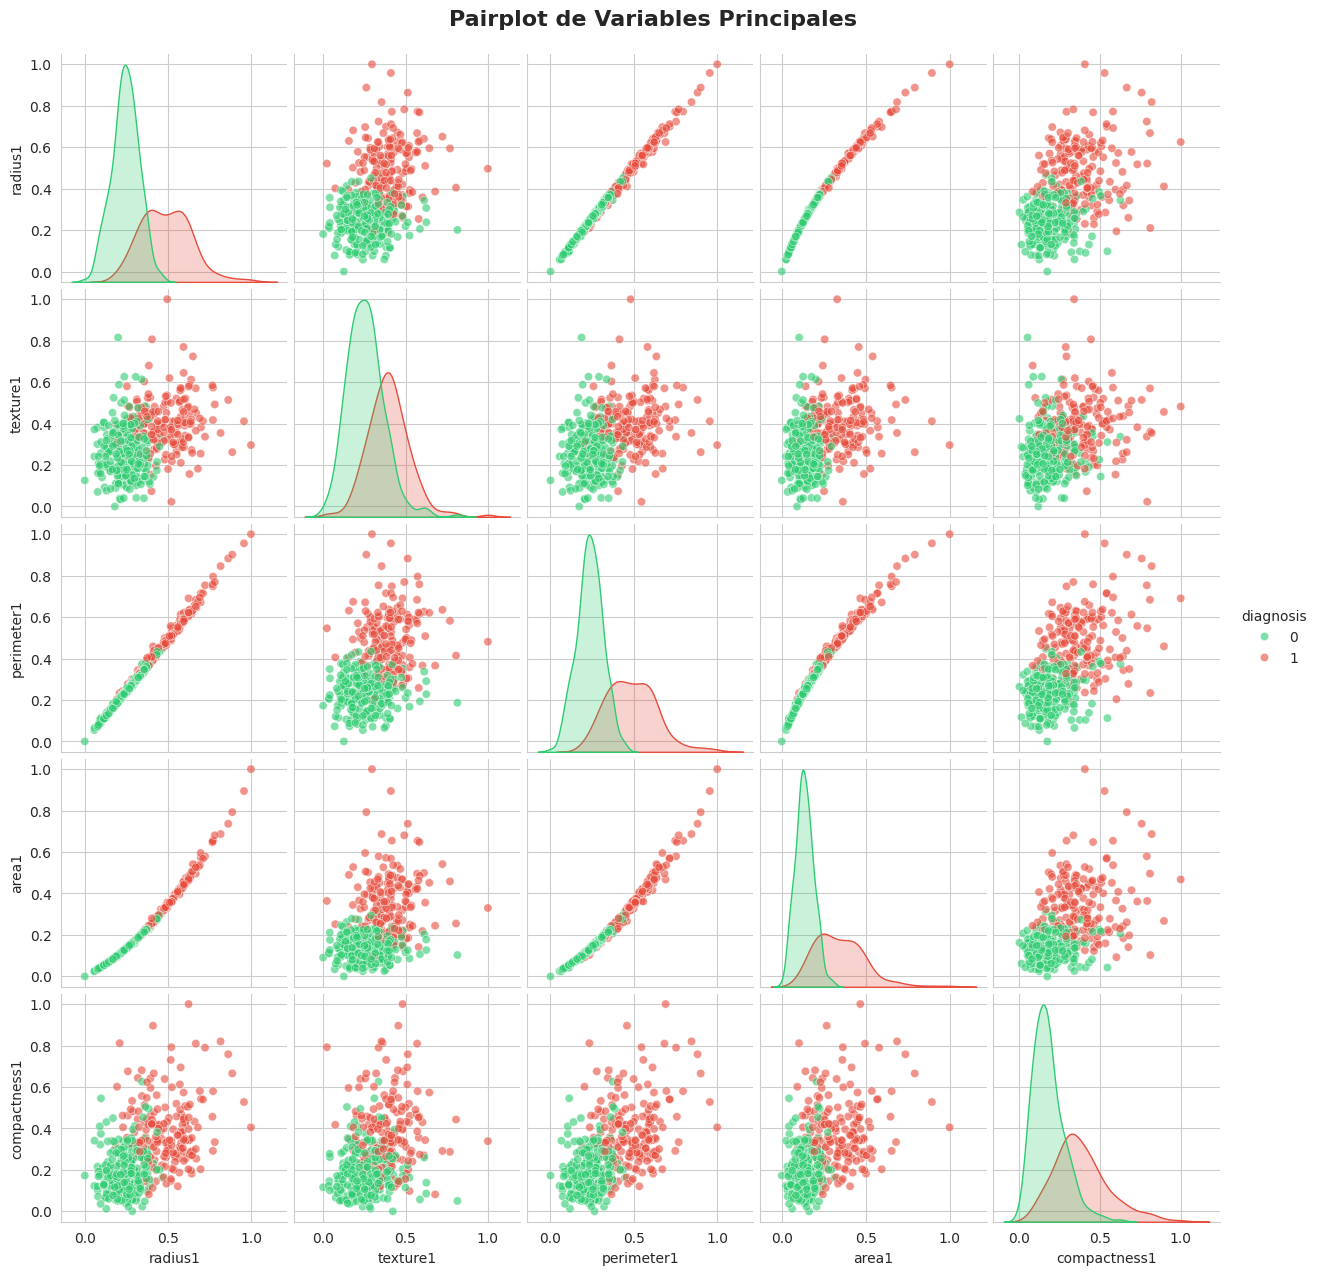

In [14]:
variables_pairplot = ['diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'compactness1']

sns.pairplot(df_train[variables_pairplot], hue='diagnosis',
             palette=['#2ecc71', '#e74c3c'],
             diag_kind='kde',
             plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot de Variables Principales', y=1.02, fontsize=16, fontweight='bold')
plt.show()

El pairplot confirma que las combinaciones de variables como `radius1` vs `perimeter1` y `radius1` vs `area1` permiten una separación visual clara entre tumores benignos y malignos. Esto sugiere que un modelo de clasificación podría lograr un buen desempeño utilizando estas características como predictores principales.

---
## Conclusiones Generales

1. El dataset no presenta valores perdidos, lo cual facilita el análisis sin necesidad de imputación.
2. Existe un ligero desbalance entre las clases benigno y maligno, que debe considerarse al entrenar modelos predictivos.
3. Las variables más relevantes para la predicción son las relacionadas con el tamaño del tumor (radius, perimeter, area) y la concavidad de sus bordes.
4. Se detectó alta multicolinealidad entre variables de tamaño, lo que sugiere que podría aplicarse reducción de dimensionalidad o selección de características.
5. La normalización de los datos se realizó con MinMaxScaler, ajustando los valores al rango [0, 1], lo cual es importante para algoritmos sensibles a la escala de las variables.
6. El desarrollo de la práctica permitió aplicar correctamente las etapas de preprocesamiento y análisis exploratorio de datos utilizando Python y sus librerías especializadas. A través de las estadísticas descriptivas y visualizaciones se logró comprender mejor el comportamiento del dataset y la relación entre las variables analizadas.
7. El análisis realizado permitió identificar variables relevantes asociadas al diagnóstico, además de evidenciar la importancia de la limpieza, transformación y exploración de datos como parte fundamental de cualquier proyecto.


---
## Aplicación en campo profesional
1. **Santiago Calle:** Como ingeniero mecatrónico los conocimientos que adquirí en esta práctica junto con los temas revisados durante la semana pueden aplicarse en mi entorno laboral para analizar información generada por máquinas, sensores y procesos automatizados.
En mi trabajo, estos conocimientos pueden utilizarse para detectar comportamientos anormales en equipos, analizar tendencias de temperatura, corriente, presión o tiempos de operación y así mejorar el mantenimiento preventivo y la eficiencia de los sistemas. También permiten organizar y limpiar datos antes de analizarlos, evitando errores y obteniendo información más confiable para la toma de decisiones.
Con el análisis exploratorio me permite tener entre variables estadísticas y gráficos, facilitando la interpretación del comportamiento de los procesos industriales y apoyando futuras implementaciones de modelos predictivos.

2. **Alexander Luna:** Al igual que con el dataset de cáncer, donde buscamos patrones celulares anómalos para detectar un tumor maligno antes de que sea tarde, en el Registro de La Propiedad podemos entrenar un modelo con el histórico de transacciones para detectar patrones inusuales en las solicitudes de inscripción (ej. cambios bruscos de propietario, horas inusuales de ingreso, o solicitudes sobre bienes con litigios). Aquí optimizaríamos el Recall para asegurar que el sistema detecte cualquier posible irregularidad antes de que pase a la firma del Registrador o Jerárquico Superior.

3. **Alvaro Quisilema:** Como ingeniero mecatrónico especializado en sistemas de seguridad y control de asistencia, este tipo de análisis de datos es directamente aplicable a mi campo profesional. Por ejemplo, puedo utilizar la misma metodología para analizar datos de sensores en dispositivos de control de acceso ( biométricos, torniquetes, cámaras) y predecir fallos antes de que ocurran, identificando qué variables como temperatura, tiempo de respuesta o voltaje son las más relevantes. De igual forma, en el área de control de asistencia, este enfoque me permite detectar patrones de ausentismo o anomalías en los registros de marcación, facilitando una gestión más eficiente y basada en datos.
